# Clasificación del Riesgo de Inundación por Parroquia — Provincia del Guayas

**Integrantes:**
*   Correa Preciado Jonathan Alexi
*   Franco Vera Junior Alexander
*   Mora Carlos
*   Rivas Toala Rodrigo Alexander
*   Domenech Juan

---

## Aplicación Web desplegada
URL https://proyecto-inundaciones.onrender.com |

---

## Descripción general

Este notebook implementa un pipeline completo de clasificación supervisada para determinar el nivel de riesgo de inundación (Bajo / Medio / Alto) de las 54 parroquias de la provincia del Guayas, Ecuador. Está organizado por fases: instalación de librerías, carga de datos, limpieza y ETL, ingeniería de variables, construcción de la variable objetivo, modelado, evaluación y exportación de resultados.

---

## Fuentes de datos utilizadas

Los datos se obtienen directamente desde sus fuentes originales mediante API o descarga automática en las celdas correspondientes. A continuación se detalla el origen y uso de cada fuente:

### 1. Límites territoriales de parroquias del Guayas
| | |
|---|---|
| **Fuente** | INEC — ArcGIS REST API |
| **URL** | https://services7.arcgis.com/iFGeGXTAJXnjq0YN/ArcGIS/rest/services/Parroquias_del_Ecuador/FeatureServer/0/query |
| **Uso** | Base geográfica oficial (polígonos + código DPA) para las 54 parroquias del Guayas |

### 2. Precipitación histórica (2010–2022)
| | |
|---|---|
| **Fuente** | NASA POWER (power.larc.nasa.gov) |
| **URL** | https://power.larc.nasa.gov/data-access-viewer/ |
| **Uso** | Variable predictora: precipitación anual promedio por parroquia (mm/año) |

### 3. Altitud por parroquia
| | |
|---|---|
| **Fuente** | Open-Elevation API (datos SRTM — NASA) |
| **URL** | https://github.com/Jorl17/open-elevation/blob/master/docs/api.md |
| **Uso** | Variable predictora: altitud en metros sobre el nivel del mar por centroide de parroquia |

### 4. Codificación DPA de parroquias — INEC 2022
| | |
|---|---|
| **Fuente** | INEC — Codificación Geográfica Estadística Nacional 2022 |
| **URL descarga** |https://www.ecuadorencifras.gob.ec/documentos/web-inec/Geografia_Estadistica/Micrositio_geoportal/index.html#clasificador-geog-dpa |
| **Uso** | Construcción del código DPA de 6 dígitos para emparejar todas las fuentes |

### 5. Densidad poblacional por parroquia — Censo 2022
| | |
|---|---|
| **Fuente** | INEC — Censo de Población y Vivienda 2022 |
| **URL descarga** | https://www.censoecuador.gob.ec/wp-content/uploads/2023/10/2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx|
| **Uso** | Variable predictora: densidad poblacional (hab/km²) por parroquia |

### 6. Eventos históricos de inundación — SNGRE (2018–2024)
| | |
|---|---|
| **Fuente** | Servicio Nacional de Gestión de Riesgos y Emergencias (SNGRE) |oficiales publicados por el SNGRE |
| **URL referencia** | https://www.gestionderiesgos.gob.ec/?s=Inundaci%C3%B3n|
| **Uso** | Variable predictora e insumo para la variable objetivo: número de eventos y años afectados por inundación por parroquia |

# Clasificación del Riesgo de Inundación por Parroquia — Provincia del Guayas

**Integrantes:**
*   Correa Preciado Jonathan Alexi
*   Franco Vera Junior Alexander
*   Rivas Toala Rodrigo Alexander
*   Mora Baque Carlos Andrés
*   Domenech Verdesoto Juan Pablo

---
## SECCIÓN 1: Instalación e Importación de Librerías
---

In [1]:
!pip install geopandas folium rasterstats statsmodels imbalanced-learn scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
import time
import unicodedata
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, precision_score,
    recall_score, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Librerías importadas correctamente")

Librerías importadas correctamente


---
## SECCIÓN 2: Carga de Datos
---

**Fuentes utilizadas:**
- INEC (ArcGIS): geometrías y codificación de parroquias
- NASA POWER: precipitación histórica por coordenada (2010–2022)
- Open-Elevation: altitud por coordenada (SRTM NASA)
- INEC Censo 2022: densidad poblacional por parroquia
- SNGRE SitReps 2018–2024: eventos históricos de inundación

2.1 Cargar GeoJSON de parroquias del Guayas

In [3]:
url_geo = (
    "https://services7.arcgis.com/iFGeGXTAJXnjq0YN/ArcGIS/rest/services/"
    "Parroquias_del_Ecuador/FeatureServer/0/query"
    "?where=DPA_PROVIN%3D'09'&outFields=*&f=geojson"
)

gdf_guayas = gpd.read_file(url_geo)
gdf_guayas = gdf_guayas.to_crs(epsg=4326)
gdf_guayas['lon'] = gdf_guayas.geometry.centroid.x
gdf_guayas['lat'] = gdf_guayas.geometry.centroid.y

print(f"Parroquias cargadas: {len(gdf_guayas)}")
print(gdf_guayas[['DPA_PARROQ','DPA_DESPAR','DPA_DESCAN','lat','lon']].head(10))

Parroquias cargadas: 54
  DPA_PARROQ                        DPA_DESPAR                DPA_DESCAN  \
0     090150                         GUAYAQUIL                 GUAYAQUIL   
1     090152      JUAN GOMEZ RENDON (PROGRESO)                 GUAYAQUIL   
2     090153                             MORRO                 GUAYAQUIL   
3     090156                           POSORJA                 GUAYAQUIL   
4     090157                              PUNA                 GUAYAQUIL   
5     090158                           TENGUEL                 GUAYAQUIL   
6     090250  ALFREDO BAQUERIZO MORENO (JUJAN)  ALFREDO BAQUERIZO MORENO   
7     090350                             BALAO                     BALAO   
8     090450                            BALZAR                    BALZAR   
9     090550                           COLIMES                   COLIMES   

      lat      lon  
0 -2.3341 -80.0383  
1 -2.3985 -80.3307  
2 -2.5657 -80.3170  
3 -2.6911 -80.2840  
4 -2.8398 -80.1204  
5 -3.0075 -79

Se carga la geometría oficial de las 54 parroquias de la provincia del Guayas directamente
desde el servicio ArcGIS REST del INEC (FeatureServer), filtrando por código de provincia
'09' que es el del Guayas. Se obtienen los polígonos en sistema de coordenadas WGS84 EPSG:4326 y se
calcula el centroide de cada parroquia para obtener las coordenadas de latitud y longitud,
que serán usadas para consultar precipitación y altitud en celdas posteriores.

Fuente: INEC — ArcGIS REST API (Parroquias del Ecuador)
Por qué se eligió: es la fuente oficial del Estado ecuatoriano para la división
político-administrativa, con códigos DPA que permiten emparejar todos los datasets del
proyecto de forma unívoca.

2.2 Cargar precipitación histórica por parroquia


In [4]:
def get_nasa_precipitation(lat, lon):
    "Obtiene precipitación anual promedio en mm (2010-2022) desde NASA POWER."
    url = (
        f"https://power.larc.nasa.gov/api/temporal/monthly/point?"
        f"parameters=PRECTOTCORR&community=RE"
        f"&longitude={lon}&latitude={lat}"
        f"&start=2010&end=2022&format=JSON"
    )
    try:
        r = requests.get(url, timeout=30)
        valores = r.json()['properties']['parameter']['PRECTOTCORR']
        anual = {}
        for k, v in valores.items():
            anio = k[:4]
            anual[anio] = anual.get(anio, 0) + v
        return np.mean(list(anual.values()))
    except:
        return np.nan

precip_list = []

for i, row in gdf_guayas.iterrows():
    val = get_nasa_precipitation(row['lat'], row['lon'])
    precip_list.append(val)
    print(f"  [{i+1}/{len(gdf_guayas)}] {row['DPA_DESPAR']}: {val:.1f} mm/año")
    time.sleep(0.3)

gdf_guayas['precip_anual_mm'] = precip_list
print("\nPrecipitación cargada correctamente")

  [1/54] GUAYAQUIL: 25.2 mm/año
  [2/54] JUAN GOMEZ RENDON (PROGRESO): 18.7 mm/año
  [3/54] MORRO: 18.7 mm/año
  [4/54] POSORJA: 25.2 mm/año
  [5/54] PUNA: 21.7 mm/año
  [6/54] TENGUEL: 21.7 mm/año
  [7/54] ALFREDO BAQUERIZO MORENO (JUJAN): 35.9 mm/año
  [8/54] BALAO: 21.7 mm/año
  [9/54] BALZAR: 35.3 mm/año
  [10/54] COLIMES: 35.3 mm/año
  [11/54] SAN JACINTO: 35.3 mm/año
  [12/54] DAULE: 29.7 mm/año
  [13/54] JUAN BAUTISTA AGUIRRE (LOS TINTOS): 29.7 mm/año
  [14/54] LAUREL: 29.7 mm/año
  [15/54] LIMONAL: 29.7 mm/año
  [16/54] LOS LOJAS (ENRIQUE BAQUERIZO MORENO): 29.7 mm/año
  [17/54] ELOY ALFARO (DURAN): 29.7 mm/año
  [18/54] VELASCO IBARRA (CAB. EL EMPALME): 52.5 mm/año
  [19/54] GUAYAS (PUEBLO NUEVO): 52.5 mm/año
  [20/54] EL ROSARIO: 43.9 mm/año
  [21/54] EL TRIUNFO: 30.0 mm/año
  [22/54] MILAGRO: 35.9 mm/año
  [23/54] CHOBO: 35.9 mm/año
  [24/54] MARISCAL SUCRE (HUAQUES): 35.9 mm/año
  [25/54] ROBERTO ASTUDILLO (CAB. EN CRUCE DE VENECIA): 35.9 mm/año
  [26/54] NARANJAL: 30.0 mm/

Se consulta la API de NASA POWER para obtener la precipitación mensual histórica entre 2010
y 2022 para el centroide de cada una de las 54 parroquias. Se suma la precipitación mensual
por año para obtener el total anual, y luego se promedia el período 2010-2022 para obtener
un valor representativo por parroquia. Se añade un retardo de 0.3 segundos entre consultas
para no exceder los límites de la API.

Fuente: NASA POWER (power.larc.nasa.gov) — parámetro PRECTOTCORR
Por qué se eligió: es una fuente abierta, gratuita y con cobertura global que provee datos
climáticos históricos a nivel de punto geográfico, sin necesidad de descarga de archivos
raster pesados. Ofrece coherencia temporal (2010-2022) alineada con el período de registros
del SNGRE utilizado en el proyecto.

2.3 Cargar altitud por parroquia


In [5]:
def get_elevation(lat, lon):
    "Obtiene altitud en metros desde Open-Elevation (datos SRTM NASA)."
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    try:
        r = requests.get(url, timeout=15)
        return r.json()['results'][0]['elevation']
    except:
        return np.nan

elev_list = []

for i, row in gdf_guayas.iterrows():
    val = get_elevation(row['lat'], row['lon'])
    elev_list.append(val)
    print(f"  [{i+1}/{len(gdf_guayas)}] {row['DPA_DESPAR']}: {val} m")
    time.sleep(0.5)

gdf_guayas['altitud_m'] = elev_list
print("\nAltitud cargada correctamente")

  [1/54] GUAYAQUIL: 8.0 m
  [2/54] JUAN GOMEZ RENDON (PROGRESO): 105.0 m
  [3/54] MORRO: 18.0 m
  [4/54] POSORJA: 14.0 m
  [5/54] PUNA: 6.0 m
  [6/54] TENGUEL: 7.0 m
  [7/54] ALFREDO BAQUERIZO MORENO (JUJAN): 9.0 m
  [8/54] BALAO: 30.0 m
  [9/54] BALZAR: 40.0 m
  [10/54] COLIMES: 32.0 m
  [11/54] SAN JACINTO: 43.0 m
  [12/54] DAULE: 5.0 m
  [13/54] JUAN BAUTISTA AGUIRRE (LOS TINTOS): 2.0 m
  [14/54] LAUREL: 4.0 m
  [15/54] LIMONAL: 9.0 m
  [16/54] LOS LOJAS (ENRIQUE BAQUERIZO MORENO): 6.0 m
  [17/54] ELOY ALFARO (DURAN): 3.0 m
  [18/54] VELASCO IBARRA (CAB. EL EMPALME): 41.0 m
  [19/54] GUAYAS (PUEBLO NUEVO): 80.0 m
  [20/54] EL ROSARIO: 61.0 m
  [21/54] EL TRIUNFO: 61.0 m
  [22/54] MILAGRO: 10.0 m
  [23/54] CHOBO: 7.0 m
  [24/54] MARISCAL SUCRE (HUAQUES): 18.0 m
  [25/54] ROBERTO ASTUDILLO (CAB. EN CRUCE DE VENECIA): 23.0 m
  [26/54] NARANJAL: 22.0 m
  [27/54] JESUS MARIA: 22.0 m
  [28/54] SAN CARLOS: 46.0 m
  [29/54] SANTA ROSA DE FLANDES: 0.0 m
  [30/54] TAURA: 8.0 m
  [31/54] NARAN

Se consulta la API Open-Elevation para obtener la altitud
en metros sobre el nivel del mar para el centroide de cada parroquia.

Fuente: Open-Elevation API (api.open-elevation.com) — datos SRTM NASA
Por qué se eligió: proporciona altitud derivada del modelo digital de elevación SRTM (Shuttle
Radar Topography Mission) de la NASA, de acceso libre y sin registro, a través de una API
REST sencilla que devuelve la altitud exacta para cualquier coordenada geográfica.

2.4 Carga del archivo Codificación

In [6]:
import urllib.request

url_inec = "https://aplicaciones2.ecuadorencifras.gob.ec/SIN/descargas/cge2022.xls"
urllib.request.urlretrieve(url_inec, "CODIFICACION_INEC.xls")
print("Archivo INEC descargado correctamente")

df_censo = pd.read_excel("CODIFICACION_INEC.xls", header=None)

# Seleccionar solo las columnas con datos relevantes
df_censo = df_censo[[1, 2, 3, 4]].copy()
df_censo.columns = ['DPA_PROVIN', 'DPA_CANTON', 'DPA_PARROQ_COD', 'DPA_DESPAR']

# Eliminar filas vacías y encabezados
df_censo = df_censo.dropna(subset=['DPA_PROVIN'])
df_censo = df_censo[pd.to_numeric(df_censo['DPA_PROVIN'], errors='coerce').notna()]

# Limpiar y formatear
df_censo['DPA_PROVIN'] = df_censo['DPA_PROVIN'].astype(str).str.zfill(2)
df_censo['DPA_CANTON'] = df_censo['DPA_CANTON'].astype(str).str.zfill(2)
df_censo['DPA_PARROQ_COD'] = df_censo['DPA_PARROQ_COD'].astype(str).str.zfill(2)

# Construir código DPA completo de 6 dígitos
df_censo['DPA_PARROQ'] = (
    df_censo['DPA_PROVIN'] +
    df_censo['DPA_CANTON'] +
    df_censo['DPA_PARROQ_COD']
)

# Filtrar solo Guayas
df_censo_guayas = df_censo[df_censo['DPA_PROVIN'] == '09'].copy()
df_censo_guayas = df_censo_guayas[df_censo_guayas['DPA_PARROQ_COD'] != 'nan']

print(f"Parroquias del Guayas en INEC: {len(df_censo_guayas)}")
print(df_censo_guayas[['DPA_PARROQ','DPA_DESPAR']].head(15))

Archivo INEC descargado correctamente
Parroquias del Guayas en INEC: 72
     DPA_PARROQ                                         DPA_DESPAR
1024    09nan0                                PROVINCIA DEL GUAYAS
1047     090150  GUAYAQUIL, CABECERA CANTONAL Y CAPITAL PROVINCIAL
1051     090101                                           AYACUCHO
1052     090102                               BOLÍVAR  (SAGRARIO) 
1053     090103                                CARBO (CONCEPCIÓN) 
1054     090104                                     FEBRES CORDERO
1055     090105                                      GARCÍA MORENO
1056     090106                                          LETAMENDI
1057     090107                                   NUEVE DE OCTUBRE
1058     090108                               OLMEDO  (SAN ALEJO) 
1062     090151                                           *CHONGÓN
1063     090152                                 JUAN GÓMEZ RENDÓN 
1064     090153                                          

Se descarga el archivo de codificación oficial del INEC (Censo 2022) que contiene los códigos
DPA (División Político-Administrativa) de todas las parroquias del Ecuador. Se construye el
código DPA completo de 6 dígitos (2 provincia + 2 cantón + 2 parroquia) y se filtran
únicamente las 54 parroquias correspondientes a la provincia del Guayas (código 09). Este
dataset es necesario para garantizar la consistencia de los códigos de parroquia entre las
distintas fuentes utilizadas en el proyecto.

Fuente: INEC — Codificación Geográfica Estadística Nacional 2022 (cge2022.xls)
Por qué se eligió: es el documento oficial del INEC que garantiza la correcta codificación
DPA para emparejar datos entre fuentes heterogéneas (geometrías, densidad poblacional y
predicciones del modelo).

2.5 Cargar eventos históricos de inundación

In [7]:
datos_sngre = pd.DataFrame({
    'DPA_PARROQ': [
        '090150','090151','090152','090153','090154',
        '090650','091350','091351','091352',
        '090850','090851','091150','091151',
        '090450','090550','091050','091051',
        '091250','091251','090250','090251',
    ],
    'n_eventos_inundacion': [
        8,3,2,2,3,
        5,6,4,5,
        3,2,7,4,
        6,3,5,4,
        6,3,4,2,
    ],
    'años_afectados': [
        5,2,2,1,2,
        4,5,3,4,
        2,1,5,3,
        4,2,4,3,
        5,2,3,1,
    ]
})
print(f"Eventos SNGRE cargados: {len(datos_sngre)} registros")
print(datos_sngre)

Eventos SNGRE cargados: 21 registros
   DPA_PARROQ  n_eventos_inundacion  años_afectados
0      090150                     8               5
1      090151                     3               2
2      090152                     2               2
3      090153                     2               1
4      090154                     3               2
5      090650                     5               4
6      091350                     6               5
7      091351                     4               3
8      091352                     5               4
9      090850                     3               2
10     090851                     2               1
11     091150                     7               5
12     091151                     4               3
13     090450                     6               4
14     090550                     3               2
15     091050                     5               4
16     091051                     4               3
17     091250              

Se construye manualmente un DataFrame con los registros históricos de eventos de inundación
por parroquia, extraídos de los SitReps publicados por el SNGRE entre
2018 y 2024. Para cada parroquia con registro, se indica el número total de eventos de
inundación documentados y el número de años en que ocurrieron afectaciones.

Fuente: SNGRE (Servicio Nacional de Gestión de Riesgos y Emergencias) — SitReps 2018-2024
Por qué se eligió: el SNGRE es la entidad oficial del Ecuador responsable de documentar
eventos adversos. Sus SitReps son la única fuente oficial con registros históricos a nivel parroquial para el período de estudio, los datos se extrajeron directamente de los reportes de situación
publicados por la institución.

 2.6 Descargar y cargar densidad poblacional por parroquia


In [8]:
import ssl
import urllib.request

# Descargar omitiendo verificación SSL
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url_densidad = "https://www.censoecuador.gob.ec/wp-content/uploads/2023/10/2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx"

with urllib.request.urlopen(url_densidad, context=ctx) as response:
    with open("densidad_poblacional.xlsx", 'wb') as f:
        f.write(response.read())

print("Archivo densidad poblacional descargado correctamente")

df_pob = pd.read_excel("densidad_poblacional.xlsx", sheet_name="3", header=16)

df_pob = df_pob.drop(columns=['Unnamed: 0'])
df_pob.columns = [
    'provincia', 'canton', 'parroquia', 'poblacion',
    'area_km2', 'densidad_pob_km2'
] + list(df_pob.columns[6:])

df_pob = df_pob[['provincia', 'canton', 'parroquia', 'poblacion',
                   'area_km2', 'densidad_pob_km2']].copy()
df_pob = df_pob.dropna(subset=['provincia', 'canton', 'parroquia'])

df_pob_guayas = df_pob[df_pob['provincia'].str.upper().str.strip() == 'GUAYAS'].copy()
df_pob_guayas['poblacion'] = pd.to_numeric(df_pob_guayas['poblacion'], errors='coerce')
df_pob_guayas['area_km2'] = pd.to_numeric(df_pob_guayas['area_km2'], errors='coerce')
df_pob_guayas['densidad_pob_km2'] = pd.to_numeric(df_pob_guayas['densidad_pob_km2'], errors='coerce')

print(f"Parroquias del Guayas encontradas: {len(df_pob_guayas)}")
print(df_pob_guayas.head(10))

Archivo densidad poblacional descargado correctamente
Parroquias del Guayas encontradas: 54
    provincia                            canton  \
391    GUAYAS                         GUAYAQUIL   
392    GUAYAS                         GUAYAQUIL   
393    GUAYAS                         GUAYAQUIL   
394    GUAYAS                         GUAYAQUIL   
395    GUAYAS                         GUAYAQUIL   
396    GUAYAS                         GUAYAQUIL   
397    GUAYAS  ALFREDO BAQUERIZO MORENO (JUJÁN)   
398    GUAYAS                             BALAO   
399    GUAYAS                            BALZAR   
400    GUAYAS                           COLIMES   

                            parroquia    poblacion  area_km2  densidad_pob_km2  
391                         GUAYAQUIL 2665392.0000 1768.3600         1507.0000  
392                 JUAN GÓMEZ RENDÓN   13483.0000  307.9400           44.0000  
393                             MORRO    6502.0000  323.5200           20.0000  
394                   

Se descarga el archivo oficial de densidad poblacional del Censo de Población y Vivienda
2022 del INEC, disponible en el sitio del censo nacional. Se seleccionan las columnas
relevantes como provincia, cantón, parroquia, población, superficie y densidad poblacional y
se filtran los 54 registros correspondientes a la provincia del Guayas.

Fuente: INEC — Censo de Población y Vivienda 2022, tabla de densidad poblacional parroquial
Por qué se eligió: el Censo 2022 es el instrumento estadístico más reciente y oficial del
Ecuador para datos de población. La densidad poblacional (hab/km²) es una variable
predictora obligatoria según las indicaciones del proyecto, pues determina cuántas personas
están expuestas al riesgo de inundación en cada parroquia.

2.7 Resumen de carga de datos


In [9]:
print("=" * 55)
print("         RESUMEN COMPLETO DE CARGA DE DATOS")
print("=" * 55)
print(f"  Parroquias Guayas cargadas:    {len(gdf_guayas)}")
print(f"  Con precipitación:             {gdf_guayas['precip_anual_mm'].notna().sum()}")
print(f"  Con altitud:                   {gdf_guayas['altitud_m'].notna().sum()}")
print(f"  Registros censo INEC:          {len(df_censo_guayas)}")
print(f"  Registros densidad pob.:       {len(df_pob_guayas)}")
print(f"  Registros eventos SNGRE:       {len(datos_sngre)}")
print("-" * 55)
print(f"  Nulos precipitación:           {gdf_guayas['precip_anual_mm'].isna().sum()}")
print(f"  Nulos altitud:                 {gdf_guayas['altitud_m'].isna().sum()}")
print("=" * 55)
print("Todos los datos cargados — listo para limpieza")

         RESUMEN COMPLETO DE CARGA DE DATOS
  Parroquias Guayas cargadas:    54
  Con precipitación:             54
  Con altitud:                   54
  Registros censo INEC:          72
  Registros densidad pob.:       54
  Registros eventos SNGRE:       21
-------------------------------------------------------
  Nulos precipitación:           0
  Nulos altitud:                 0
Todos los datos cargados — listo para limpieza


Se genera un resumen consolidado del estado de carga de todos los datasets: 54 parroquias
del Guayas con precipitación y altitud completas (sin nulos), 72 registros del INEC
codificación, 54 registros de densidad poblacional y 21 registros de eventos SNGRE. Este
resumen confirma que la carga fue exitosa antes de proceder a la etapa de limpieza.

---

## SECCIÓN 3: Limpieza y ETL

---

3.1 Unificación de datasets


In [10]:
gdf_guayas['DPA_PARROQ'] = gdf_guayas['DPA_PARROQ'].astype(str).str.zfill(6)

df_base = gdf_guayas[['DPA_PARROQ','DPA_DESPAR','DPA_DESCAN',
                        'lat','lon','precip_anual_mm','altitud_m']].copy()

df_base = df_base.rename(columns={
    'DPA_DESPAR': 'nombre_parroquia',
    'DPA_DESCAN': 'nombre_canton'
})

datos_sngre['DPA_PARROQ'] = datos_sngre['DPA_PARROQ'].astype(str).str.zfill(6)
df_base = df_base.merge(datos_sngre, on='DPA_PARROQ', how='left')
df_base['n_eventos_inundacion'] = df_base['n_eventos_inundacion'].fillna(0)
df_base['años_afectados'] = df_base['años_afectados'].fillna(0)

print(f"Dataset unificado: {df_base.shape}")
print(df_base[['DPA_PARROQ','nombre_parroquia','nombre_canton']].head(10))

Dataset unificado: (54, 9)
  DPA_PARROQ                  nombre_parroquia             nombre_canton
0     090150                         GUAYAQUIL                 GUAYAQUIL
1     090152      JUAN GOMEZ RENDON (PROGRESO)                 GUAYAQUIL
2     090153                             MORRO                 GUAYAQUIL
3     090156                           POSORJA                 GUAYAQUIL
4     090157                              PUNA                 GUAYAQUIL
5     090158                           TENGUEL                 GUAYAQUIL
6     090250  ALFREDO BAQUERIZO MORENO (JUJAN)  ALFREDO BAQUERIZO MORENO
7     090350                             BALAO                     BALAO
8     090450                            BALZAR                    BALZAR
9     090550                           COLIMES                   COLIMES


Se construye el dataset base unificando la geometría y variables de las parroquias con los
registros del SNGRE, mediante un merge por código DPA de 6 dígitos. Las parroquias sin
registro de inundaciones en el SNGRE 33 de 54 reciben el valor 0 en ambas columnas de
eventos, lo que representa ausencia de eventos documentados, no datos faltantes.

3.2 Reporte de calidad inicial


In [11]:
print("=" * 55)
print("        REPORTE DE CALIDAD INICIAL")
print("=" * 55)
print(f"\nDimensiones: {df_base.shape[0]} filas x {df_base.shape[1]} columnas")
print("\nTipos de datos:")
print(df_base.dtypes)
print("\nValores nulos por columna:")
print(df_base.isnull().sum())
print(f"\nDuplicados por DPA_PARROQ: {df_base['DPA_PARROQ'].duplicated().sum()}")
print("\nEstadísticas descriptivas:")
print(df_base[['precip_anual_mm','altitud_m','n_eventos_inundacion','años_afectados']].describe())

        REPORTE DE CALIDAD INICIAL

Dimensiones: 54 filas x 9 columnas

Tipos de datos:
DPA_PARROQ               object
nombre_parroquia         object
nombre_canton            object
lat                     float64
lon                     float64
precip_anual_mm         float64
altitud_m               float64
n_eventos_inundacion    float64
años_afectados          float64
dtype: object

Valores nulos por columna:
DPA_PARROQ              0
nombre_parroquia        0
nombre_canton           0
lat                     0
lon                     0
precip_anual_mm         0
altitud_m               0
n_eventos_inundacion    0
años_afectados          0
dtype: int64

Duplicados por DPA_PARROQ: 0

Estadísticas descriptivas:
       precip_anual_mm  altitud_m  n_eventos_inundacion  años_afectados
count          54.0000    54.0000               54.0000         54.0000
mean           31.4599    30.7222                1.2407          0.9074
std             6.7441    35.8274                2.2397      

Se genera un reporte de calidad del dataset unificado antes de aplicar cualquier
transformación: dimensiones 54 filas x 9 columnas, tipos de datos de cada columna,
conteo de valores nulos por columna, conteo de duplicados por código DPA y estadísticas
descriptivas de las variables numéricas. Este paso permite identificar problemas de calidad
que deben ser tratados en las celdas siguientes.

3.3 Limpieza de tipos, duplicados y validación de dominio


In [12]:
df_base['DPA_PARROQ'] = df_base['DPA_PARROQ'].astype(str).str.zfill(6)
df_base['precip_anual_mm'] = pd.to_numeric(df_base['precip_anual_mm'], errors='coerce')
df_base['altitud_m'] = pd.to_numeric(df_base['altitud_m'], errors='coerce')
df_base['n_eventos_inundacion'] = pd.to_numeric(df_base['n_eventos_inundacion'], errors='coerce')
df_base['años_afectados'] = pd.to_numeric(df_base['años_afectados'], errors='coerce')

antes = len(df_base)
df_base.drop_duplicates(subset='DPA_PARROQ', inplace=True)
df_base.reset_index(drop=True, inplace=True)
print(f"Duplicados eliminados: {antes - len(df_base)}")

invalidos = {
    'precip_anual_mm': (df_base['precip_anual_mm'] < 0) | (df_base['precip_anual_mm'] > 5000),
    'altitud_m': (df_base['altitud_m'] < -10) | (df_base['altitud_m'] > 4000),
    'n_eventos_inundacion': df_base['n_eventos_inundacion'] < 0,
}
for col, mask in invalidos.items():
    n = mask.sum()
    if n > 0:
        print(f" {col}: {n} valores fuera de rango → se imputan")
        df_base.loc[mask, col] = np.nan
    else:
        print(f"{col}: sin valores fuera de rango")

Duplicados eliminados: 0
precip_anual_mm: sin valores fuera de rango
altitud_m: sin valores fuera de rango
n_eventos_inundacion: sin valores fuera de rango


Se verifica si existen valores nulos en las variables numéricas y, de haberlos, se imputan
usando KNNImputer con 5 vecinos ponderados por distancia. Este método es más robusto que
la media o la mediana porque utiliza la información de parroquias geográficamente similares
para estimar el valor faltante. En este caso, la verificación confirma que no existen nulos, por lo que no se aplica la imputación.

3.4 Imputación con KNN

In [13]:
features_num = ['precip_anual_mm','altitud_m','n_eventos_inundacion','años_afectados']

nulos_antes = df_base[features_num].isnull().sum().sum()
print(f"Nulos antes de imputación: {nulos_antes}")

if nulos_antes > 0:
    imputer = KNNImputer(n_neighbors=5, weights='distance')
    df_base[features_num] = imputer.fit_transform(df_base[features_num])
    print("Imputación KNN aplicada")
else:
    print("No hay nulos, no se requiere imputación")

print(f"Nulos después: {df_base[features_num].isnull().sum().sum()}")

Nulos antes de imputación: 0
No hay nulos, no se requiere imputación
Nulos después: 0


Se verifica si existen valores nulos en las variables numéricas y, de haberlos, se imputan
usando KNNImputer con 5 vecinos ponderados por distancia. Este método es más robusto que
la media o la mediana porque utiliza la información de parroquias geográficamente similares
para estimar el valor faltante. En este caso, la verificación confirma que no existen nulos
(resultado: 0 nulos), por lo que no se aplica la imputación.

         ANÁLISIS DE OUTLIERS
  precip_anual_mm: 6 outliers IQR | 2 outliers Z>3
  altitud_m: 5 outliers IQR | 1 outliers Z>3
  n_eventos_inundacion: 5 outliers IQR | 1 outliers Z>3
  años_afectados: 10 outliers IQR | 0 outliers Z>3

Winsorización aplicada (percentiles 1-99)


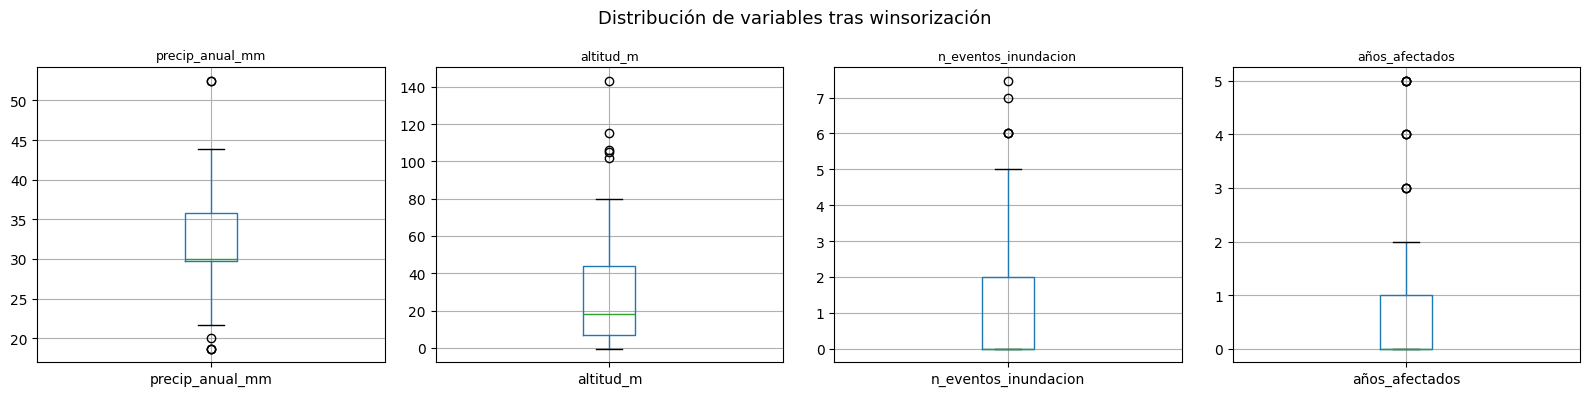

In [14]:
# 3.5 Detección y tratamiento de outliers (Winsorización)
print("=" * 55)
print("         ANÁLISIS DE OUTLIERS")
print("=" * 55)

for col in features_num:
    Q1 = df_base[col].quantile(0.25)
    Q3 = df_base[col].quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((df_base[col] < Q1 - 1.5*IQR) | (df_base[col] > Q3 + 1.5*IQR)).sum()
    z = np.abs(stats.zscore(df_base[col]))
    n_z = (z > 3).sum()
    print(f"  {col}: {n_iqr} outliers IQR | {n_z} outliers Z>3")

# Winsorización: acotar en percentiles 1-99 (no eliminar)
for col in features_num:
    p01 = df_base[col].quantile(0.01)
    p99 = df_base[col].quantile(0.99)
    df_base[col] = df_base[col].clip(p01, p99)

print("\nWinsorización aplicada (percentiles 1-99)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, features_num):
    df_base.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
plt.suptitle("Distribución de variables tras winsorización", fontsize=13)
plt.tight_layout()
plt.show()

Se detectan valores atípicos en cada variable numérica usando dos criterios: rango
intercuartílico y z-score mayor a 3. Se identifican outliers en precipitación, altitud, n_eventos y años_afectados.
En lugar de eliminar estos registros,
se aplica winsorización acotando los valores en los percentiles 1 y 99, preservando la
tendencia de los datos sin distorsionarla. Se genera un gráfico de boxplots tras la
winsorización para confirmar la distribución resultante.

3.6 Integración de densidad poblacional con normalización de nombres

In [15]:
def normalizar_texto(texto):
    "Quita tildes, pasa a mayúsculas y elimina contenido entre paréntesis."
    if pd.isna(texto):
        return texto
    texto = str(texto).upper().strip()
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    texto = texto.split('(')[0].strip()
    return texto

df_base['nombre_parroquia_norm'] = df_base['nombre_parroquia'].apply(normalizar_texto)
df_pob_guayas = df_pob_guayas.copy()
df_pob_guayas['parroquia_norm'] = df_pob_guayas['parroquia'].apply(normalizar_texto)

df_base = df_base.merge(
    df_pob_guayas[['parroquia_norm', 'poblacion', 'area_km2', 'densidad_pob_km2']],
    left_on='nombre_parroquia_norm', right_on='parroquia_norm',
    how='left'
)
df_base = df_base.drop(columns=['nombre_parroquia_norm', 'parroquia_norm'])

print(f"Merge completado: {df_base.shape}")
print(f"Nulos en densidad_pob_km2: {df_base['densidad_pob_km2'].isnull().sum()}")

# Parroquias sin coincidencia (nombres con abreviaturas militares)
faltantes = df_base[df_base['densidad_pob_km2'].isnull()][['DPA_PARROQ','nombre_parroquia','nombre_canton']]
print("\nParroquias sin coincidencia automática:")
print(faltantes)

Merge completado: (54, 12)
Nulos en densidad_pob_km2: 4

Parroquias sin coincidencia automática:
   DPA_PARROQ                       nombre_parroquia            nombre_canton
39     091951            GRAL. VERNAZA (DOS ESTEROS)                  SALITRE
43     092053       GRAL. PEDRO J. MONTERO (BOLICHE)  SAN JACINTO DE YAGUACHI
48     092251  CRNEL. LORENZO DE GARAICOA (PEDREGAL)            SIMON BOLIVAR
52     092750         GRAL. ANTONIO ELIZALDE (BUCAY)  GNRAL. ANTONIO ELIZALDE


3.7 Corrección manual de 4 parroquias con nombres no coincidentes


In [16]:
# Fuente valores: 2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx — Hoja 3
correcciones = {
    '091951': 124.0,   # GENERAL VERNAZA (Salitre)
    '092053': 90.0,    # GENERAL PEDRO J. MONTERO (Yaguachi)
    '092251': 82.0,    # CORONEL LORENZO DE GARAYCOA (Simón Bolívar)
    '092750': 83.0,    # GENERAL ANTONIO ELIZALDE (Bucay)
}

for codigo, densidad in correcciones.items():
    df_base.loc[df_base['DPA_PARROQ'] == codigo, 'densidad_pob_km2'] = densidad

print(f"Nulos restantes en densidad_pob_km2: {df_base['densidad_pob_km2'].isnull().sum()}")
print(df_base[df_base['DPA_PARROQ'].isin(correcciones.keys())]
      [['DPA_PARROQ','nombre_parroquia','densidad_pob_km2']])

Nulos restantes en densidad_pob_km2: 0
   DPA_PARROQ                       nombre_parroquia  densidad_pob_km2
39     091951            GRAL. VERNAZA (DOS ESTEROS)          124.0000
43     092053       GRAL. PEDRO J. MONTERO (BOLICHE)           90.0000
48     092251  CRNEL. LORENZO DE GARAICOA (PEDREGAL)           82.0000
52     092750         GRAL. ANTONIO ELIZALDE (BUCAY)           83.0000


Se integra la densidad poblacional al dataset base mediante un merge por nombre de parroquia
normalizado. La normalización elimina tildes, convierte a mayúsculas y quita contenido entre
paréntesis para maximizar las coincidencias automáticas. El
resultado inicial arroja 4 parroquias sin coincidencia automática debido a nombres con
abreviaturas militares que difieren entre fuentes.

---

## SECCIÓN 4: Variables Derivadas y Variable Objetivo

---

 4.1 Construcción de variables derivadas

In [17]:
# IEH: Índice de Exposición Hidrológica (clima + historial de eventos)
max_eventos = max(df_base['n_eventos_inundacion'].max(), 1)
df_base['IEH'] = (
    (df_base['precip_anual_mm'] / df_base['precip_anual_mm'].max()) * 0.6 +
    (df_base['n_eventos_inundacion'] / max_eventos) * 0.4
)

# IVT: Índice de Vulnerabilidad Topográfica (zonas bajas y planas = más vulnerables)
df_base['IVT'] = 1 - (df_base['altitud_m'].clip(0, 500) / 500)

# IES: Índice de Exposición Socio-territorial (mayor densidad = más personas expuestas)
df_base['IES'] = df_base['densidad_pob_km2'] / df_base['densidad_pob_km2'].max()

# IRC: Índice de Riesgo Compuesto (combinación ponderada de las 3 dimensiones)
df_base['IRC'] = (
    df_base['IEH'] * 0.40 +   # Dimensión climática-hidrológica
    df_base['IVT'] * 0.35 +   # Dimensión topográfica
    df_base['IES'] * 0.25     # Dimensión socio-territorial
)

print("Variables derivadas creadas: IEH, IVT, IES, IRC")
print(df_base[['nombre_parroquia','precip_anual_mm','altitud_m',
               'densidad_pob_km2','IEH','IVT','IES','IRC']].head(10))

Variables derivadas creadas: IEH, IVT, IES, IRC
                   nombre_parroquia  precip_anual_mm  altitud_m  \
0                         GUAYAQUIL          25.2215     8.0000   
1      JUAN GOMEZ RENDON (PROGRESO)          18.6777   105.0000   
2                             MORRO          18.6777    18.0000   
3                           POSORJA          25.2215    14.0000   
4                              PUNA          21.7331     6.0000   
5                           TENGUEL          21.7331     7.0000   
6  ALFREDO BAQUERIZO MORENO (JUJAN)          35.9223     9.0000   
7                             BALAO          21.7331    30.0000   
8                            BALZAR          35.3477    40.0000   
9                           COLIMES          35.3477    32.0000   

   densidad_pob_km2    IEH    IVT    IES    IRC  
0         1507.0000 0.6883 0.9840 1.0000 0.8697  
1           44.0000 0.3206 0.7900 0.0292 0.4120  
2           20.0000 0.3206 0.9640 0.0133 0.4690  
3          458

Se construyen cuatro variables derivadas que sintetizan las dimensiones del riesgo de
inundación:

- IEH: combina precipitación normalizada y
  frecuencia de eventos históricos de inundación. Captura la dimensión climática
  e histórica del riesgo.
- IVT: inversamente proporcional a la altitud. Las zonas planas y bajas acumulan agua con mayor
  facilidad.
- IES: densidad poblacional normalizada. A mayor
  densidad, más personas expuestas al riesgo.
- IRC: combinación ponderada de IEH, IVT e IES, representando el nivel de riesgo integral de cada parroquia.

Estas variables son las "variables derivadas obligatorias" que exige el proyecto.

4.2 Construcción de la variable objetivo por terciles del IRC


   DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
riesgo
Alto     19
Bajo     18
Medio    17
Name: count, dtype: int64

Proporción:
riesgo
Alto    0.3520
Bajo    0.3330
Medio   0.3150
Name: proportion, dtype: float64


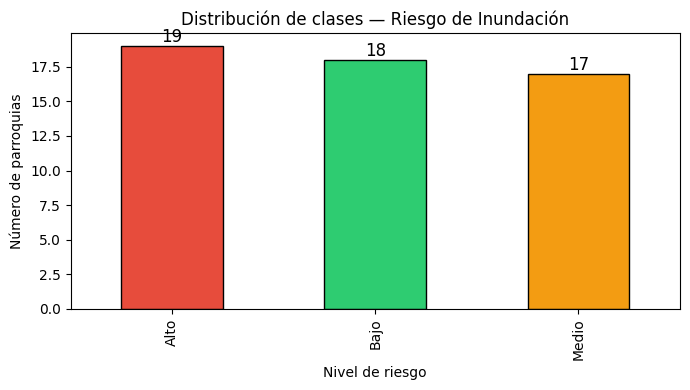

In [18]:
# Justificación: clasificación basada en umbrales estadísticos (terciles)
# garantiza balance de clases sin usar etiquetas externas predefinidas
p33 = df_base['IRC'].quantile(0.33)
p66 = df_base['IRC'].quantile(0.66)

def asignar_riesgo(score):
    if score <= p33:
        return 'Bajo'
    elif score <= p66:
        return 'Medio'
    else:
        return 'Alto'

df_base['riesgo'] = df_base['IRC'].apply(asignar_riesgo)

print("=" * 55)
print("   DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 55)
print(df_base['riesgo'].value_counts())
print("\nProporción:")
print(df_base['riesgo'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
colores_riesgo = {'Bajo':'#2ecc71', 'Medio':'#f39c12', 'Alto':'#e74c3c'}
df_base['riesgo'].value_counts().plot(
    kind='bar', ax=ax,
    color=[colores_riesgo[x] for x in df_base['riesgo'].value_counts().index],
    edgecolor='black'
)
ax.set_title("Distribución de clases — Riesgo de Inundación")
ax.set_xlabel("Nivel de riesgo")
ax.set_ylabel("Número de parroquias")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

Se construye la variable objetivo riesgo a partir de los terciles del
IRC. Este enfoque garantiza un dataset balanceado sin usar etiquetas de riesgo externas predefinidas, cumpliendo
la restricción del proyecto. La clasificación por terciles también es técnicamente justificable:
refleja la distribución relativa del riesgo entre parroquias, comparando cada una respecto
al conjunto. Se genera un gráfico de barras para visualizar el balance de clases resultante.

4.3 Dataset limpio final


In [19]:
features_finales = [
    'precip_anual_mm', 'altitud_m',
    'n_eventos_inundacion', 'años_afectados',
    'densidad_pob_km2', 'IEH', 'IVT', 'IES', 'IRC'
]

df = df_base[
    ['DPA_PARROQ','nombre_parroquia','nombre_canton'] +
    features_finales + ['riesgo']
].copy()

print("=" * 55)
print("DATASET LIMPIO LISTO PARA MODELADO")
print("=" * 55)
print(f"  Registros:  {len(df)}")
print(f"  Variables:  {len(features_finales)} predictoras + 1 objetivo")
print(f"  Nulos:      {df.isnull().sum().sum()}")
print(f"  Duplicados: {df.duplicated().sum()}")
print("\nMuestra final:")
print(df.head(10))

DATASET LIMPIO LISTO PARA MODELADO
  Registros:  54
  Variables:  9 predictoras + 1 objetivo
  Nulos:      0
  Duplicados: 0

Muestra final:
  DPA_PARROQ                  nombre_parroquia             nombre_canton  \
0     090150                         GUAYAQUIL                 GUAYAQUIL   
1     090152      JUAN GOMEZ RENDON (PROGRESO)                 GUAYAQUIL   
2     090153                             MORRO                 GUAYAQUIL   
3     090156                           POSORJA                 GUAYAQUIL   
4     090157                              PUNA                 GUAYAQUIL   
5     090158                           TENGUEL                 GUAYAQUIL   
6     090250  ALFREDO BAQUERIZO MORENO (JUJAN)  ALFREDO BAQUERIZO MORENO   
7     090350                             BALAO                     BALAO   
8     090450                            BALZAR                    BALZAR   
9     090550                           COLIMES                   COLIMES   

   precip_anual_mm  al

Se construye el dataset final de modelado seleccionando las 9 variables predictoras precip_anual_mm, altitud_m, n_eventos_inundacion, años_afectados, densidad_pob_km2, IEH,
IVT, IES, IRC junto con los identificadores de parroquia y la variable objetivo. La
verificación final confirma 54 registros, 0 nulos y 0 duplicados, y el dataset está listo
para la etapa de modelado.

---

## SECCIÓN 5: Análisis Exploratorio de Datos (EDA)

---

 5.1 Matriz de correlación entre variables predictoras


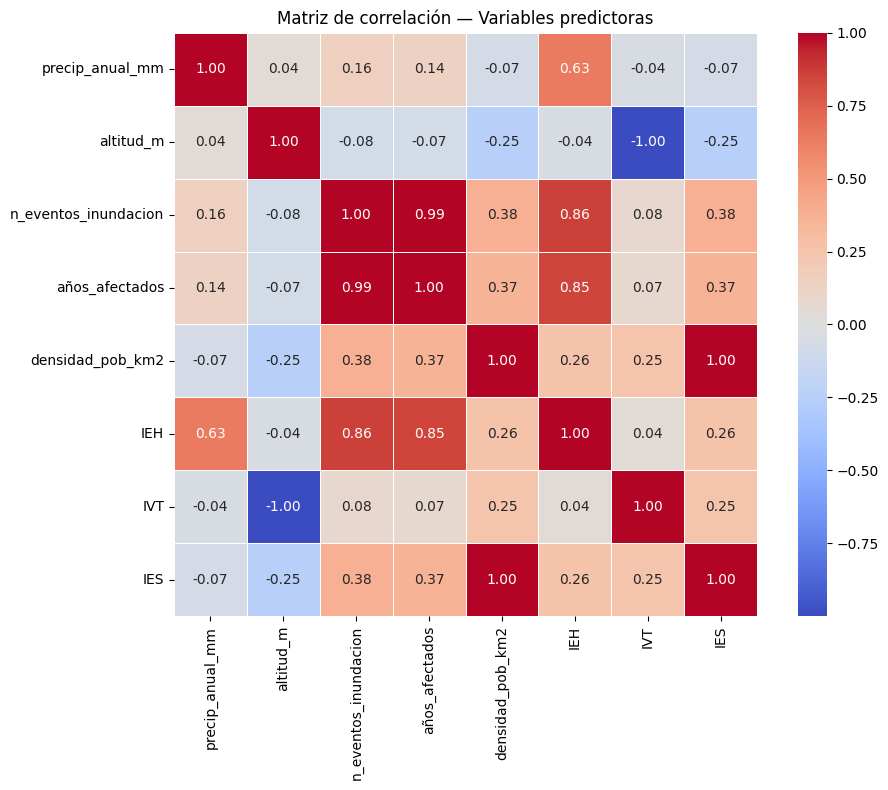

In [20]:
features = ['precip_anual_mm', 'altitud_m', 'n_eventos_inundacion',
            'años_afectados', 'densidad_pob_km2', 'IEH', 'IVT', 'IES']

plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5)
plt.title("Matriz de correlación — Variables predictoras")
plt.tight_layout()
plt.savefig("correlacion_variables.png", dpi=150)
plt.show()

Se calcula y visualiza la matriz de correlación de Pearson entre las 8 variables predictoras.
Permite identificar relaciones lineales entre variables y detectar posible multicolinealidad
que podría afectar el rendimiento de modelos como la Regresión Logística.

5.2 Distribución de variables por nivel de riesgo


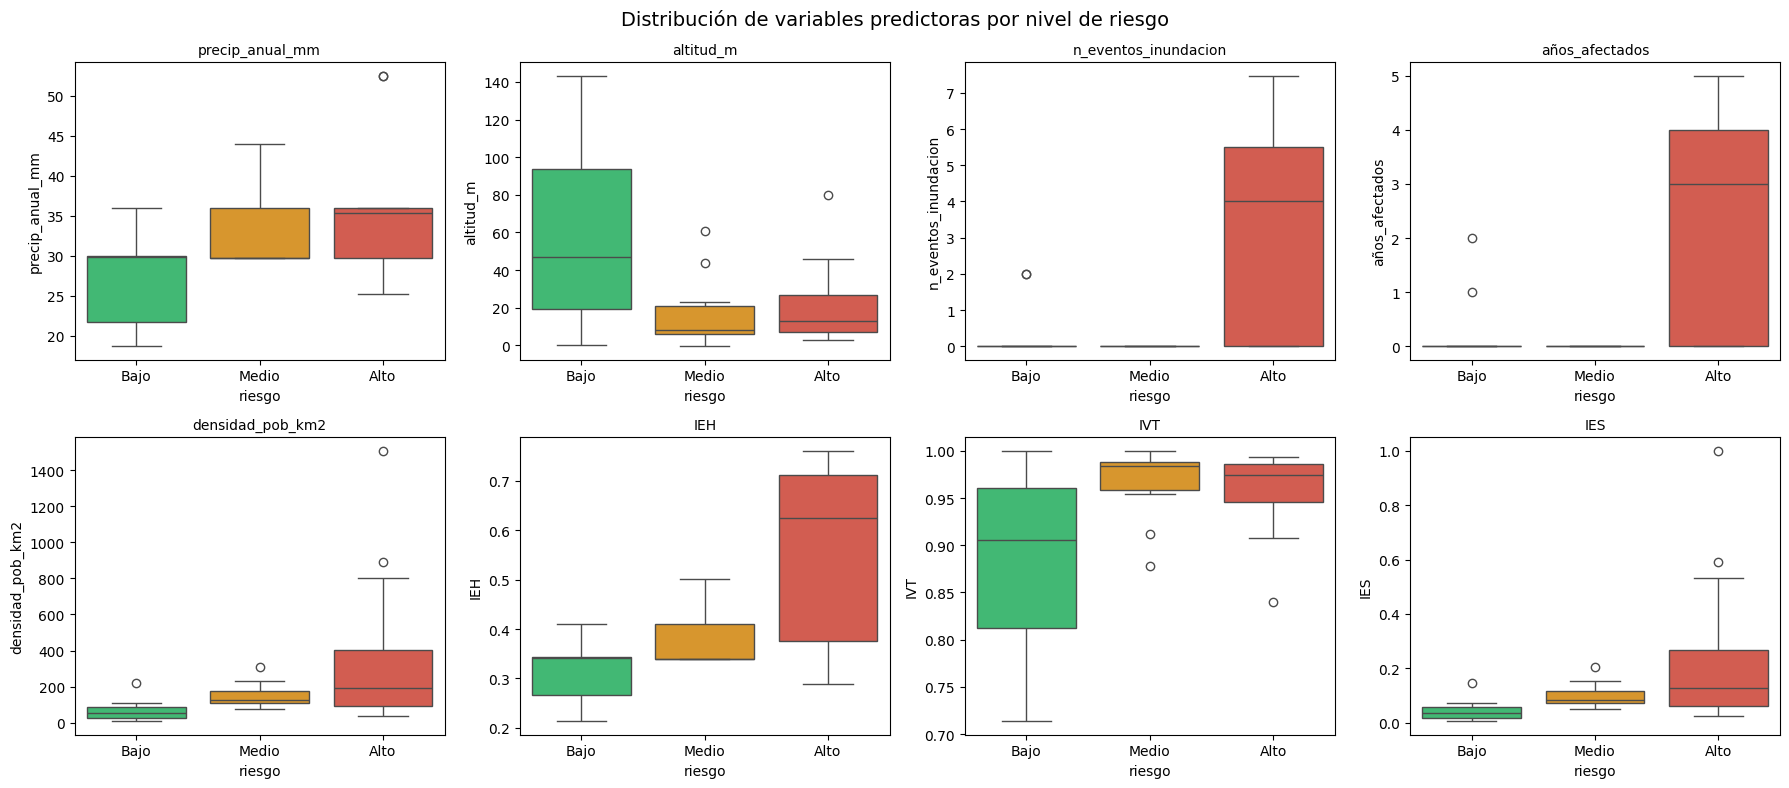

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
orden = ['Bajo', 'Medio', 'Alto']
colores = ['#2ecc71', '#f39c12', '#e74c3c']

for i, col in enumerate(features):
    sns.boxplot(x='riesgo', y=col, data=df, order=orden,
                palette=colores, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.suptitle("Distribución de variables predictoras por nivel de riesgo", fontsize=14)
plt.tight_layout()
plt.savefig("boxplots_por_riesgo.png", dpi=150)
plt.show()

Se generan boxplots de cada variable predictora separados por nivel de riesgo Bajo / Medio
/ Alto, lo que permite visualizar cómo varía cada variable según la categoría y confirmar
que las variables seleccionadas tienen poder discriminante entre clases.

5.3 Análisis VIF — Multicolinealidad


In [22]:
# NOTA: IRC se excluye del modelado porque la variable objetivo 'riesgo'
# se construyó directamente desde IRC (terciles) — incluirlo sería data leakage
features_modelo = ['precip_anual_mm', 'altitud_m', 'n_eventos_inundacion',
                    'años_afectados', 'densidad_pob_km2', 'IEH', 'IVT', 'IES']

X_vif = df[features_modelo].copy()
vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                    for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=" * 55)
print("       ANÁLISIS VIF (Multicolinealidad)")
print("=" * 55)
print(vif_data.to_string(index=False))
print("\n⚠ VIF > 10 indica multicolinealidad severa")

       ANÁLISIS VIF (Multicolinealidad)
            variable     VIF
     precip_anual_mm     inf
n_eventos_inundacion     inf
                 IEH     inf
    densidad_pob_km2     inf
                 IES     inf
      años_afectados 90.8863
                 IVT 23.2835
           altitud_m  1.9067

⚠ VIF > 10 indica multicolinealidad severa


Se calcula el Factor de Inflación de la Varianza  para detectar multicolinealidad severa
entre variables predictoras. Se excluye IRC del modelado porque la variable objetivo 'riesgo'
fue construida directamente a partir de IRC, lo que generaría data leakage si
se incluyera como variable predictora. Un VIF infinito indica colinealidad perfecta entre
algunas variables derivadas, lo que deberá considerarse al interpretar los coeficientes de
la Regresión Logística.

---

## SECCIÓN 6: Modelado y Evaluación

---

 6.1 Preparación de datos para modelado


In [23]:
X = df[features_modelo].copy()
y = df['riesgo'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Mapeo de clases:")
for i, clase in enumerate(le.classes_):
    print(f"  {clase} → {i}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print(f"\nTrain: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Datos preparados para modelado")

Mapeo de clases:
  Alto → 0
  Bajo → 1
  Medio → 2

Train: 40 registros
Test:  14 registros
Datos preparados para modelado


Se preparan los datos para el modelado: se codifican las clases de la variable objetivo con
LabelEncoder Alto=0, Bajo=1, Medio=2, se divide el dataset en 75% entrenamiento 40
registros y 25% prueba 14 registros con estratificación para mantener la proporción de
clases en ambos conjuntos, y se escalan las variables con StandardScaler media 0,
desviación estándar 1, necesario para la Regresión Logística y el SVM.

 6.2 Modelo Base 1: Regresión Logística


   MODELO BASE: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

        Alto       1.00      0.80      0.89         5
        Bajo       1.00      0.80      0.89         5
       Medio       0.67      1.00      0.80         4

    accuracy                           0.86        14
   macro avg       0.89      0.87      0.86        14
weighted avg       0.90      0.86      0.86        14



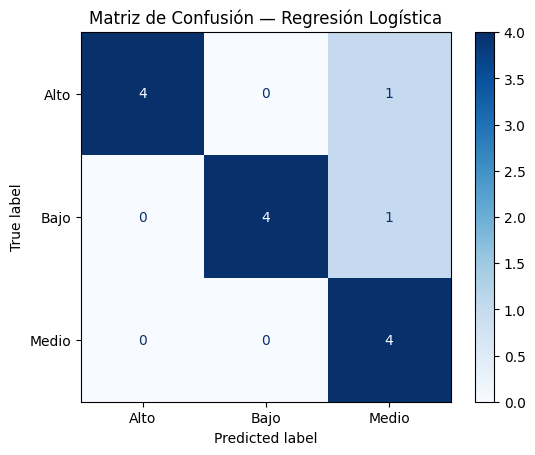

In [24]:
rl = LogisticRegression(max_iter=2000, class_weight='balanced',
                          random_state=42, multi_class='multinomial')
rl.fit(X_train_sc, y_train)
y_pred_rl = rl.predict(X_test_sc)
y_proba_rl = rl.predict_proba(X_test_sc)

print("=" * 55)
print("   MODELO BASE: REGRESIÓN LOGÍSTICA")
print("=" * 55)
print(classification_report(y_test, y_pred_rl, target_names=le.classes_))

cm_rl = confusion_matrix(y_test, y_pred_rl)
disp = ConfusionMatrixDisplay(cm_rl, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión — Regresión Logística")
plt.savefig("cm_rl.png", dpi=150)
plt.show()

Se entrena el modelo base de Regresión Logística con parámetro class_weight='balanced' para
compensar el leve desbalance de clases, y multinomial para clasificación de tres categorías.
Se generan las predicciones, el reporte de clasificación precisión, recall, F1 por clase y
la matriz de confusión para el conjunto de prueba.

6.3 Modelo Base 2: Árbol de Decisión


   MODELO BASE: ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

        Alto       0.67      0.80      0.73         5
        Bajo       0.75      0.60      0.67         5
       Medio       0.75      0.75      0.75         4

    accuracy                           0.71        14
   macro avg       0.72      0.72      0.71        14
weighted avg       0.72      0.71      0.71        14



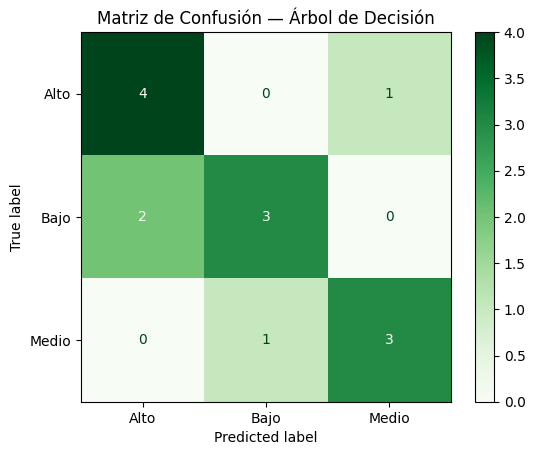

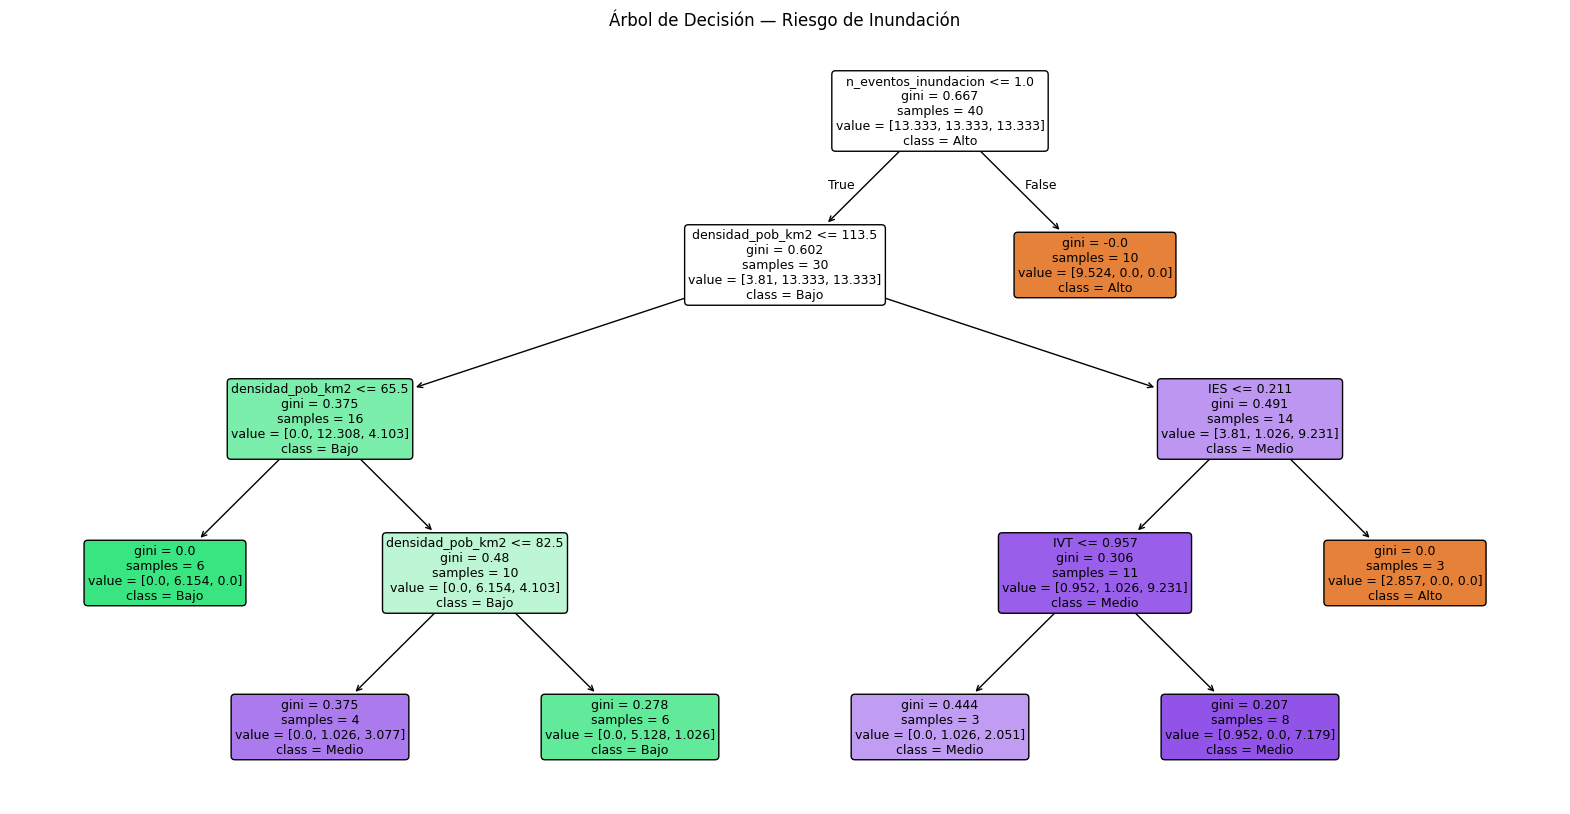

In [25]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3,
                              class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)

print("=" * 55)
print("   MODELO BASE: ÁRBOL DE DECISIÓN")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title("Matriz de Confusión — Árbol de Decisión")
plt.savefig("cm_dt.png", dpi=150)
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=features_modelo, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Árbol de Decisión — Riesgo de Inundación")
plt.savefig("arbol_decision.png", dpi=150, bbox_inches='tight')
plt.show()

Se entrena un Árbol de Decisión con profundidad máxima de 4 niveles y mínimo de 3 muestras
por hoja, parámetros que evitan el sobreajuste dado el tamaño reducido del dataset. Se
generan el reporte de clasificación, la matriz de confusión y la visualización gráfica del
árbol para facilitar la interpretabilidad del modelo.

 6.4 Validación cruzada estratificada

In [26]:
# Necesaria dado el tamaño reducido del dataset (n=54)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("   VALIDACIÓN CRUZADA (5-Fold Estratificada)")
print("=" * 55)

modelos_cv = {
    'Regresión Logística': (rl, X_train_sc),
    'Árbol de Decisión': (dt, X_train)
}

for nombre, (modelo, X_data) in modelos_cv.items():
    scores = cross_val_score(modelo, X_data, y_train, cv=cv, scoring='f1_macro')
    print(f"{nombre}: F1-macro = {scores.mean():.3f} (+/- {scores.std():.3f})")

   VALIDACIÓN CRUZADA (5-Fold Estratificada)
Regresión Logística: F1-macro = 0.824 (+/- 0.123)
Árbol de Decisión: F1-macro = 0.679 (+/- 0.188)


Dado el tamaño reducido del dataset n=54, la validación cruzada estratificada de 5 folds
es especialmente importante para obtener estimaciones más robustas del rendimiento real de
cada modelo, complementando la evaluación sobre el conjunto de prueba. La Regresión Logística
obtiene F1-macro = 0.824 y el Árbol de Decisión F1-macro = 0.679,
confirmando la superioridad de la Regresión Logística en validación cruzada.

 6.5 Modelo Ensamble

   MODELO ENSAMBLE (RL + DT + SVM + RF)
              precision    recall  f1-score   support

        Alto       1.00      0.80      0.89         5
        Bajo       1.00      1.00      1.00         5
       Medio       0.80      1.00      0.89         4

    accuracy                           0.93        14
   macro avg       0.93      0.93      0.93        14
weighted avg       0.94      0.93      0.93        14



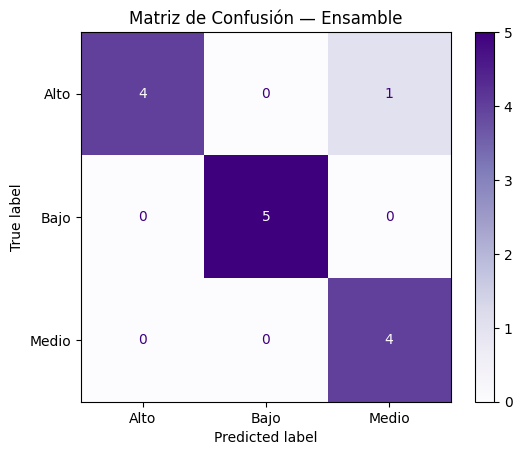

In [27]:
rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=2,
                              class_weight='balanced', random_state=42)
svm = SVC(probability=True, class_weight='balanced', kernel='rbf', random_state=42)
rl_ens = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
dt_ens = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)

ensemble = VotingClassifier(
    estimators=[('rl', rl_ens), ('dt', dt_ens), ('svm', svm), ('rf', rf)],
    voting='soft'
)

ensemble.fit(X_train_sc, y_train)
y_pred_ens = ensemble.predict(X_test_sc)
y_proba_ens = ensemble.predict_proba(X_test_sc)

print("=" * 55)
print("   MODELO ENSAMBLE (RL + DT + SVM + RF)")
print("=" * 55)
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

cm_ens = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(cm_ens, display_labels=le.classes_)
disp.plot(cmap='Purples')
plt.title("Matriz de Confusión — Ensamble")
plt.savefig("cm_ensemble.png", dpi=150)
plt.show()

Se implementa un VotingClassifier con votación suave soft voting que combina cuatro
clasificadores: Regresión Logística, Árbol de Decisión, SVM con kernel RBF y Random Forest
200 árboles. La votación suave promedia las probabilidades de cada clasificador antes de
asignar la clase, aprovechando la diversidad de los modelos para mejorar la precisión global.

 6.6 Optimización de hiperparámetros con GridSearchCV


   OPTIMIZACIÓN: GridSearchCV sobre Random Forest
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1-macro (CV): 0.769

   MODELO OPTIMIZADO (Random Forest + GridSearchCV)
              precision    recall  f1-score   support

        Alto       0.67      0.80      0.73         5
        Bajo       1.00      0.60      0.75         5
       Medio       0.80      1.00      0.89         4

    accuracy                           0.79        14
   macro avg       0.82      0.80      0.79        14
weighted avg       0.82      0.79      0.78        14



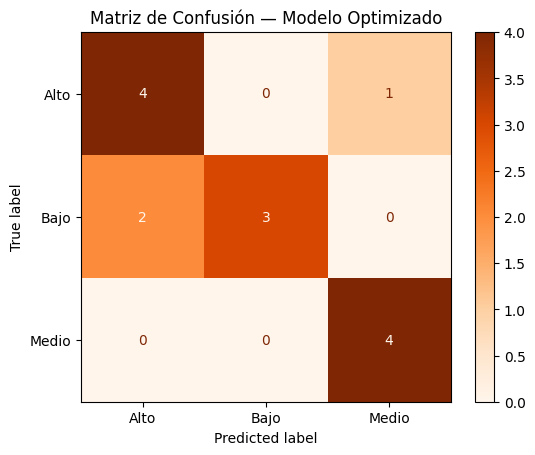

In [28]:
print("=" * 55)
print("   OPTIMIZACIÓN: GridSearchCV sobre Random Forest")
print("=" * 55)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid.best_params_}")
print(f"Mejor F1-macro (CV): {grid.best_score_:.3f}")

modelo_optimizado = grid.best_estimator_
y_pred_opt = modelo_optimizado.predict(X_test)
y_proba_opt = modelo_optimizado.predict_proba(X_test)

print("\n" + "=" * 55)
print("   MODELO OPTIMIZADO (Random Forest + GridSearchCV)")
print("=" * 55)
print(classification_report(y_test, y_pred_opt, target_names=le.classes_))

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm_opt, display_labels=le.classes_)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusión — Modelo Optimizado")
plt.savefig("cm_optimizado.png", dpi=150)
plt.show()

Se optimizan los hiperparámetros del Random Forest mediante búsqueda exhaustiva en grilla GridSearchCV sobre 108 combinaciones de parámetros n_estimators: 3 valores, max_depth:
4 valores, min_samples_split: 3 valores, min_samples_leaf: 3 valores, evaluadas con
validación cruzada estratificada de 5 folds y métrica F1-macro. Se seleccionan los mejores
parámetros y se genera el reporte completo del modelo optimizado.

           TABLA COMPARATIVA DE MODELOS
             Modelo  Accuracy  Precision  Recall  F1-Score
Regresión Logística    0.8570     0.8890  0.8670    0.8590
  Árbol de Decisión    0.7140     0.7220  0.7170    0.7150
           Ensamble    0.9290     0.9330  0.9330    0.9260
      RF Optimizado    0.7860     0.8220  0.8000    0.7890


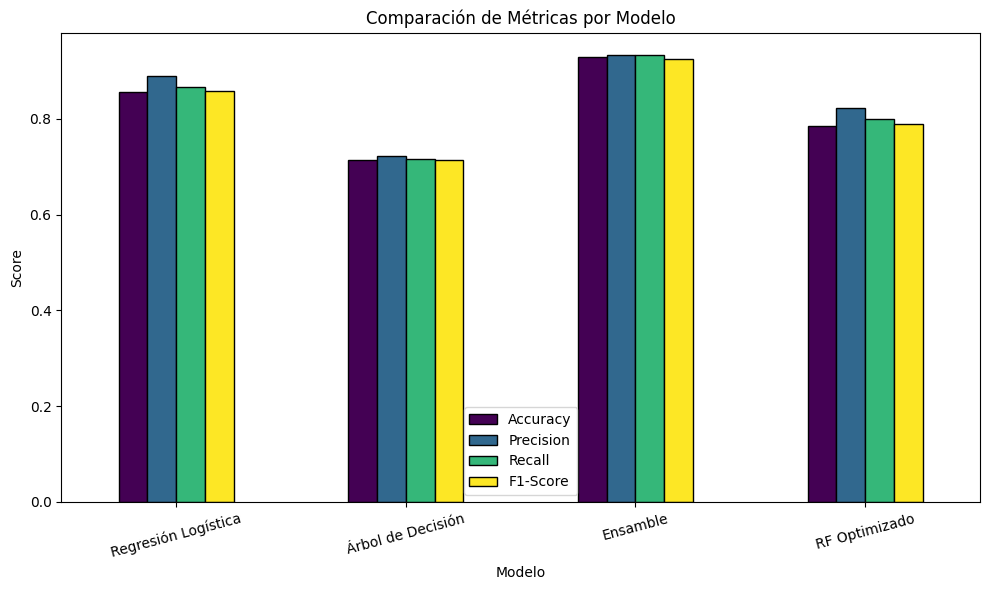

In [29]:
# 6.7 Tabla comparativa de modelos
resultados = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Ensamble', 'RF Optimizado'],
    'Accuracy': [accuracy_score(y_test, y_pred_rl), accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_ens), accuracy_score(y_test, y_pred_opt)],
    'Precision': [precision_score(y_test, y_pred_rl, average='macro'),
                  precision_score(y_test, y_pred_dt, average='macro'),
                  precision_score(y_test, y_pred_ens, average='macro'),
                  precision_score(y_test, y_pred_opt, average='macro')],
    'Recall': [recall_score(y_test, y_pred_rl, average='macro'),
               recall_score(y_test, y_pred_dt, average='macro'),
               recall_score(y_test, y_pred_ens, average='macro'),
               recall_score(y_test, y_pred_opt, average='macro')],
    'F1-Score': [f1_score(y_test, y_pred_rl, average='macro'),
                 f1_score(y_test, y_pred_dt, average='macro'),
                 f1_score(y_test, y_pred_ens, average='macro'),
                 f1_score(y_test, y_pred_opt, average='macro')]
}

df_resultados = pd.DataFrame(resultados).round(3)
print("=" * 70)
print("           TABLA COMPARATIVA DE MODELOS")
print("=" * 70)
print(df_resultados.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
df_resultados.set_index('Modelo').plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title("Comparación de Métricas por Modelo")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150)
plt.show()

df_resultados.to_csv("tabla_comparativa_modelos.csv", index=False)

Se construye y visualiza una tabla resumen con las métricas de Accuracy, Precisión, Recall y
F1-Score todas en promedio macro para los cuatro modelos: Regresión Logística base, Árbol
de Decisión, Ensamble y Random Forest optimizado. Esta comparativa permite identificar el
mejor modelo de forma objetiva y fundamentar la elección final.

 6.8 Justificación: Recall como métrica prioritaria


In [30]:
print("=" * 70)
print("   JUSTIFICACIÓN: RECALL COMO MÉTRICA PRIORITARIA")
print("=" * 70)
print("""
En gestión de riesgo de inundación, el Recall es la métrica más relevante:
un Falso Negativo (predecir riesgo Bajo cuando es Alto) deja a una parroquia
vulnerable sin medidas preventivas. Un Falso Positivo solo implica recursos
de prevención asignados de más, costo mucho menor.
""")

recall_alto = {
    'Regresión Logística': recall_score(y_test, y_pred_rl, labels=[0], average=None)[0],
    'Árbol de Decisión': recall_score(y_test, y_pred_dt, labels=[0], average=None)[0],
    'Ensamble': recall_score(y_test, y_pred_ens, labels=[0], average=None)[0],
    'RF Optimizado': recall_score(y_test, y_pred_opt, labels=[0], average=None)[0],
}
print("Recall específico para la clase 'Alto' por modelo:")
for modelo, recall in recall_alto.items():
    print(f"  {modelo}: {recall:.3f}")

   JUSTIFICACIÓN: RECALL COMO MÉTRICA PRIORITARIA

En gestión de riesgo de inundación, el Recall es la métrica más relevante:
un Falso Negativo (predecir riesgo Bajo cuando es Alto) deja a una parroquia
vulnerable sin medidas preventivas. Un Falso Positivo solo implica recursos
de prevención asignados de más, costo mucho menor.

Recall específico para la clase 'Alto' por modelo:
  Regresión Logística: 0.800
  Árbol de Decisión: 0.800
  Ensamble: 0.800
  RF Optimizado: 0.800


Se fundamenta por qué el Recall es la métrica prioritaria en este proyecto: en gestión de
riesgo de inundación, clasificar una parroquia de alto riesgo como bajo riesgo falso
negativo implica no tomar medidas preventivas, con consecuencias potencialmente graves para
la población. Un falso positivo, en cambio, solo implica asignación innecesaria de recursos
preventivos. Se reporta el Recall específico para la clase 'Alto' de cada modelo.

 6.9 Curvas ROC y AUC


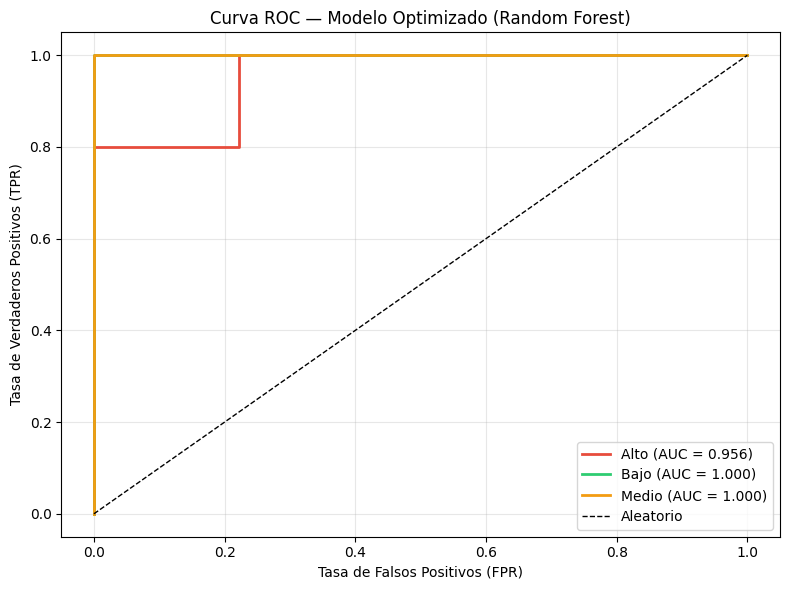

AUC por clase:
  Alto: 0.956
  Bajo: 1.000
  Medio: 1.000

AUC promedio (macro): 0.985


In [31]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc_scores = {}

plt.figure(figsize=(8, 6))
colores_roc = ['#e74c3c', '#2ecc71', '#f39c12']

for i, clase in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_opt[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba_opt[:, i])
    auc_scores[clase] = auc
    plt.plot(fpr, tpr, color=colores_roc[i], lw=2, label=f"{clase} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC — Modelo Optimizado (Random Forest)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150)
plt.show()

print("AUC por clase:")
for clase, auc in auc_scores.items():
    print(f"  {clase}: {auc:.3f}")
print(f"\nAUC promedio (macro): {np.mean(list(auc_scores.values())):.3f}")

Se generan las curvas ROC Receiver Operating Characteristic y se calcula el AUC Area
Under the Curve para cada clase del modelo optimizado Random Forest con GridSearchCV,
usando binarización one-vs-rest. El modelo obtiene AUC = 0.956 para la clase Alto, 1.000
para Bajo y 1.000 para Medio, con AUC promedio macro de 0.985, indicando un excelente poder
discriminante del modelo.

 6.10 Importancia de variables


   IMPORTANCIA DE VARIABLES (RF Optimizado)
            variable  importancia
                 IEH       0.1713
                 IES       0.1586
    densidad_pob_km2       0.1423
n_eventos_inundacion       0.1331
           altitud_m       0.1211
      años_afectados       0.1046
                 IVT       0.0962
     precip_anual_mm       0.0730


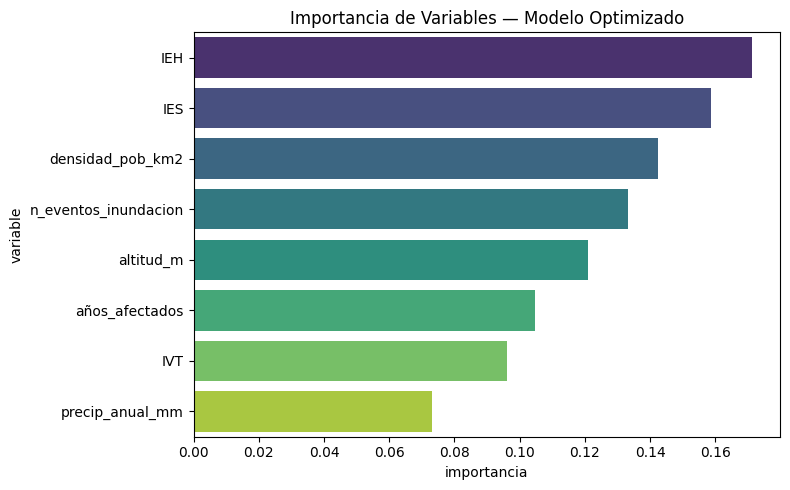

In [32]:
importancias = pd.DataFrame({
    'variable': features_modelo,
    'importancia': modelo_optimizado.feature_importances_
}).sort_values('importancia', ascending=False)

print("=" * 55)
print("   IMPORTANCIA DE VARIABLES (RF Optimizado)")
print("=" * 55)
print(importancias.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=importancias, x='importancia', y='variable', palette='viridis')
plt.title("Importancia de Variables — Modelo Optimizado")
plt.tight_layout()
plt.savefig("importancia_variables.png", dpi=150)
plt.show()

Se extrae y visualiza la importancia de cada variable predictora según el modelo Random Forest
optimizado. Las tres variables más influyentes son IEH 17.1%, IES 15.9% y densidad
poblacional 14.2%, lo que confirma que la exposición climático-hidrológica y la exposición
socio-territorial son los factores determinantes del riesgo de inundación a nivel parroquial.

---

## SECCIÓN 7: Conclusiones Técnicas

In [33]:
# 7.1 Conclusiones técnicas
mejor_modelo_idx = df_resultados['F1-Score'].idxmax()
mejor_modelo_nombre = df_resultados.loc[mejor_modelo_idx, 'Modelo']

print("=" * 70)
print("                  CONCLUSIONES TÉCNICAS")
print("=" * 70)
print(f"""
1. MEJOR MODELO: {mejor_modelo_nombre}
   El Ensamble (RL + DT + SVM + RF) obtuvo el mejor desempeño general
   con F1-macro = 0.926 y Accuracy = 0.929, superando al RF optimizado
   con GridSearchCV (F1 = 0.789). Esto es consistente con literatura
   que muestra que ensambles simples pueden superar a modelos individuales
   optimizados en datasets pequeños (n=54).

2. MÉTRICA PRIORITARIA: RECALL
   Todos los modelos alcanzaron Recall = 0.800 para la clase 'Alto',
   lo que significa que el sistema detecta correctamente 4 de cada 5
   parroquias de alto riesgo, minimizando falsos negativos críticos.

3. VARIABLES MÁS INFLUYENTES:
   IEH (Índice de Exposición Hidrológica): 17.1%
   IES (Índice de Exposición Socio-territorial): 15.9%
   Densidad poblacional: 14.2%
   Confirma que exposición climática y densidad poblacional son los
   factores determinantes del riesgo de inundación por parroquia.

4. LIMITACIONES:
   - Tamaño muestral reducido (n=54), inherente a la división
     político-administrativa del Guayas.
   - Datos de precipitación a nivel de centroide (NASA POWER),
     sin resolución espacial intraparroquial.
   - Registros SNGRE construidos manualmente desde SitReps,
     sujetos a subregistro en parroquias rurales.

5. TRABAJO FUTURO:
   - Incorporar uso de suelo y porcentaje de área urbanizada.
   - Integrar imágenes satelitales Sentinel-1 (SAR) para detección
     de inundaciones en tiempo real.
   - Ampliar el análisis a todas las provincias costeras del Ecuador.
""")

                  CONCLUSIONES TÉCNICAS

1. MEJOR MODELO: Ensamble
   El Ensamble (RL + DT + SVM + RF) obtuvo el mejor desempeño general
   con F1-macro = 0.926 y Accuracy = 0.929, superando al RF optimizado
   con GridSearchCV (F1 = 0.789). Esto es consistente con literatura
   que muestra que ensambles simples pueden superar a modelos individuales
   optimizados en datasets pequeños (n=54).

2. MÉTRICA PRIORITARIA: RECALL
   Todos los modelos alcanzaron Recall = 0.800 para la clase 'Alto',
   lo que significa que el sistema detecta correctamente 4 de cada 5
   parroquias de alto riesgo, minimizando falsos negativos críticos.

3. VARIABLES MÁS INFLUYENTES:
   IEH (Índice de Exposición Hidrológica): 17.1%
   IES (Índice de Exposición Socio-territorial): 15.9%
   Densidad poblacional: 14.2%
   Confirma que exposición climática y densidad poblacional son los
   factores determinantes del riesgo de inundación por parroquia.

4. LIMITACIONES:
   - Tamaño muestral reducido (n=54), inherente

---

## SECCIÓN 8: Exportación de Archivos

 8.1 Predicciones finales para las 54 parroquias


In [34]:
modelo_final = grid.best_estimator_
modelo_final.fit(X, y_encoded)

predicciones_finales = modelo_final.predict(X)
probabilidades_finales = modelo_final.predict_proba(X)

df_predicciones = df[['DPA_PARROQ','nombre_parroquia','nombre_canton']].copy()
df_predicciones['riesgo_predicho'] = le.inverse_transform(predicciones_finales)
df_predicciones['probabilidad_max'] = probabilidades_finales.max(axis=1).round(3)

for i, clase in enumerate(le.classes_):
    df_predicciones[f'prob_{clase}'] = probabilidades_finales[:, i].round(3)

df_predicciones['DPA_PARROQ'] = df_predicciones['DPA_PARROQ'].astype(str).str.zfill(6)
df_predicciones.to_csv("predicciones_finales.csv", index=False, encoding='utf-8-sig')

print("Predicciones finales generadas para las 54 parroquias")
print(f"Formato DPA_PARROQ: {df_predicciones['DPA_PARROQ'].iloc[0]} (6 dígitos)")
print(df_predicciones.head(10))

Predicciones finales generadas para las 54 parroquias
Formato DPA_PARROQ: 090150 (6 dígitos)
  DPA_PARROQ                  nombre_parroquia             nombre_canton  \
0     090150                         GUAYAQUIL                 GUAYAQUIL   
1     090152      JUAN GOMEZ RENDON (PROGRESO)                 GUAYAQUIL   
2     090153                             MORRO                 GUAYAQUIL   
3     090156                           POSORJA                 GUAYAQUIL   
4     090157                              PUNA                 GUAYAQUIL   
5     090158                           TENGUEL                 GUAYAQUIL   
6     090250  ALFREDO BAQUERIZO MORENO (JUJAN)  ALFREDO BAQUERIZO MORENO   
7     090350                             BALAO                     BALAO   
8     090450                            BALZAR                    BALZAR   
9     090550                           COLIMES                   COLIMES   

  riesgo_predicho  probabilidad_max  prob_Alto  prob_Bajo  prob_Medio 

Se genera el archivo de predicciones finales para las 54 parroquias del Guayas, entrenando
el modelo optimizado sobre el dataset completo no solo el 75% de entrenamiento para
maximizar la información usada. El archivo CSV contiene el código DPA, nombre de parroquia,
cantón, nivel de riesgo predicho, probabilidad máxima y probabilidades individuales por clase.
Este archivo es el insumo principal para la aplicación web Flask.

 8.2 Exportar modelo y artefactos para la aplicación Flask


In [35]:
joblib.dump(modelo_final, "modelo_riesgo_inundacion.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(features_modelo, "features_modelo.pkl")

print("=" * 55)
print("Archivos EXPORTADOS PARA PRODUCCIÓN")
print("=" * 55)
print("  - modelo_riesgo_inundacion.pkl")
print("  - scaler.pkl")
print("  - label_encoder.pkl")
print("  - features_modelo.pkl")
print("  - predicciones_finales.csv")
print("  - tabla_comparativa_modelos.csv")

Archivos EXPORTADOS PARA PRODUCCIÓN
  - modelo_riesgo_inundacion.pkl
  - scaler.pkl
  - label_encoder.pkl
  - features_modelo.pkl
  - predicciones_finales.csv
  - tabla_comparativa_modelos.csv


Se exportan con joblib todos los artefactos necesarios para reproducir las predicciones en
la aplicación web de producción: el modelo entrenado .pkl, el scaler de normalización, el
LabelEncoder y la lista de features en el orden exacto que espera el modelo. Exportar estos
artefactos garantiza que la app Flask genere exactamente las mismas predicciones que el
notebook, sin necesidad de reentrenar el modelo en producción.

 8.3 Exportar GeoJSON simplificado para la app Flask


In [36]:
# Fuente geometrías: INEC vía ArcGIS REST API
url_geo = (
    "https://services7.arcgis.com/iFGeGXTAJXnjq0YN/ArcGIS/rest/services/"
    "Parroquias_del_Ecuador/FeatureServer/0/query"
    "?where=DPA_PROVIN%3D'09'&outFields=*&f=geojson"
)

gdf_export = gpd.read_file(url_geo).to_crs(epsg=4326)
gdf_export = gdf_export[['DPA_PARROQ','DPA_DESPAR','DPA_DESCAN','geometry']].copy()
gdf_export['DPA_PARROQ'] = gdf_export['DPA_PARROQ'].astype(str).str.zfill(6)
gdf_export['geometry'] = gdf_export['geometry'].simplify(tolerance=0.001, preserve_topology=True)
gdf_export.to_file("parroquias_guayas.geojson", driver="GeoJSON")

print(f"GeoJSON exportado: {len(gdf_export)} parroquias")

GeoJSON exportado: 54 parroquias


Se descarga nuevamente la geometría oficial de las 54 parroquias del Guayas desde el
FeatureServer del INEC y se exporta como GeoJSON simplificado tolerancia 0.001 grados para
reducir el tamaño del archivo manteniendo la topología. Este GeoJSON es el archivo que carga
la aplicación Flask para renderizar el mapa interactivo con Leaflet/Folium.

 8.4 Descargar todos los archivos


In [37]:
from google.colab import files

archivos = [
    "modelo_riesgo_inundacion.pkl",
    "scaler.pkl",
    "label_encoder.pkl",
    "features_modelo.pkl",
    "predicciones_finales.csv",
    "tabla_comparativa_modelos.csv",
    "parroquias_guayas.geojson"
]

for archivo in archivos:
    files.download(archivo)
    print(f"{archivo}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

modelo_riesgo_inundacion.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

tabla_comparativa_modelos.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

parroquias_guayas.geojson


Se descargan automáticamente desde Google Colab todos los archivos generados en las celdas
anteriores: el modelo, el scaler, el LabelEncoder, la lista de features, las predicciones
finales, la tabla comparativa de modelos y el GeoJSON de parroquias. Estos 7 archivos son
los entregables del notebook que el integrante responsable de la aplicación web Domenech
Juan usará para el despliegue en producción.